# Ablation Studies for ECS Time-Series Classification
## Addressing Reviewer 2, Issues 4 and 5

**Issue 4** — *Component attribution*: Compare full ECS with simpler alternatives
(single-scale ECC, raw time-window features) and assess the K-window strategy
and AdaBoost extension.

**Issue 5** — *Added value of topology on ECG5000*: Compare the ECS feature at
$(r^*, k^*)$ with simple time-domain and shapelet features from the same temporal region.

### Ablation map
| Label | Description | Addresses |
|-------|-------------|-----------|
| **A1** | ECC (K=1, no temporal partitioning) vs ECS (K=K*) | Issue 4 |
| **A2** | K-sensitivity sweep: AUC vs K for single-feature classifier | Issue 4 |
| **A3** | ECS single-feature vs ECS AdaBoost | Issue 4 |
| **B1** | Mean amplitude in best window k* (single threshold) | Issue 5 |
| **B2** | Std of amplitude in best window k* | Issue 5 |
| **B3** | Range (max−min) in best window k* | Issue 5 |
| **B4** | Multi-stat (mean+std+range) in best window k* + AdaBoost | Issue 5 |
| **B5** | Shapelet distance from best window k* | Issue 5 |
| **B6** | ECS feature at (r*, k*) — exact comparison point | Issue 5 |


In [ ]:
# Install required packages (run once)
!pip install gudhi aeon numba imbalanced-learn -q


In [ ]:
# ============================================================
# Section 0 — Imports and global style
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

from numba import njit
from gudhi import AlphaComplex
from scipy.interpolate import griddata

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix
)
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from aeon.datasets import load_classification

plt.rcParams.update({
    "font.family"    : "serif",
    "font.size"      : 12,
    "axes.labelsize" : 13,
    "axes.titlesize" : 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth" : 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top"      : True,
    "ytick.right"    : True,
    "legend.frameon" : False,
})

print("All imports successful.")


All imports successful.


## Section 1 — Data Loading (ECG5000, binary classes 1 & 2)

In [ ]:
# ============================================================
# Load ECG5000 — binary subset (classes 1 and 2 only)
# This matches the experimental protocol of the main manuscript.
# ============================================================
Dataset_name    = "ECGFiveDays"
REQUIRED_LENGTH = 136
DIM             = 3
DELAY           = 1
SCALE_MAX       = 3.5

X_train_raw, y_train_raw = load_classification(Dataset_name, split="train")
X_test_raw,  y_test_raw  = load_classification(Dataset_name, split="test")

# Filter to exact length and finite values
def filter_and_binary(X, y, length, class_a, class_b):
    X = np.asarray(X)
    y = np.asarray(y)
    keep = [i for i in range(len(X))
            if X[i].size == length and np.isfinite(X[i]).all()
            and y[i] in (class_a, class_b)]
    Xf = X[keep];  yf = y[keep]
    labs = sorted(np.unique(yf))
    ybin = (yf == labs[1]).astype(int)
    return Xf, yf, ybin, labs

X_tr, y_tr_str, y_bin_tr, labels = filter_and_binary(
    X_train_raw, y_train_raw, REQUIRED_LENGTH, "1", "2")
X_te, y_te_str, y_bin_te, _      = filter_and_binary(
    X_test_raw,  y_test_raw,  REQUIRED_LENGTH, "1", "2")

print(f"Train: {X_tr.shape}  positives={y_bin_tr.sum()}")
print(f"Test : {X_te.shape}  positives={y_bin_te.sum()}")
print(f"Classes: {labels}")


Train: (23, 1, 136)  positives=9
Test : (861, 1, 136)  positives=433
Classes: [np.str_('1'), np.str_('2')]


/tmp/ipykernel_7467/1082206815.py:11: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train_raw, y_train_raw = load_classification(Dataset_name, split="train")
/tmp/ipykernel_7467/1082206815.py:12: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test_raw,  y_test_raw  = load_classification(Dataset_name, split="test")


## Section 2 — Core ECS Functions (identical to main manuscript)

In [ ]:
# ============================================================
# These functions are IDENTICAL to the main manuscript code.
# No modifications — ensures ablations use the same pipeline.
# ============================================================

@njit
def takens_embed_numba(ts, dim, delay):
    L = ts.shape[0]
    M = L - (dim - 1) * delay
    if M <= 0:
        return np.empty((0, dim), dtype=np.float64)
    out = np.empty((M, dim), dtype=np.float64)
    for k in range(dim):
        start = k * delay
        for i in range(M):
            out[i, k] = ts[start + i]
    return out


@njit
def compute_chi_curve_numba(f_vals, f_dims, scales):
    n      = f_vals.shape[0]
    m      = scales.shape[0]
    out    = np.empty(m, dtype=np.int64)
    order  = np.argsort(f_vals)
    s_vals = f_vals[order]
    s_dims = f_dims[order]
    chi    = 0
    ptr    = 0
    for i in range(m):
        thr = scales[i] * scales[i]
        while ptr < n and s_vals[ptr] <= thr:
            if (s_dims[ptr] % 2) == 0:
                chi += 1
            else:
                chi -= 1
            ptr += 1
        out[i] = chi
    return out


def ecs_grid_for_sample(ts, window, dim, delay, scale_max):
    """
    Compute the ECS feature vector (window × window flattened) for one sample.
    Uses K non-overlapping windows on the Takens point cloud.
    """
    ts_flat   = np.asarray(ts, dtype=float).flatten()
    pc        = takens_embed_numba(ts_flat, dim, delay)
    total_pts = pc.shape[0]
    step      = total_pts // window + (1 if total_pts % window != 0 else 0)
    scales    = np.linspace(1e-20, scale_max, window)

    if total_pts < 3:
        return np.zeros(window * window), scales

    x_v, y_v, z_v = [], [], []

    for block_id in range(window):
        start = block_id * step
        end   = total_pts if block_id == window - 1 else start + step
        block = pc[start:end]

        if block.shape[0] < 3:
            continue

        st   = AlphaComplex(points=block.tolist()).create_simplex_tree()
        filt = list(st.get_filtration())

        if not filt:
            vals = np.array([0.0]);  dims = np.array([0])
        else:
            vals = np.array([f[1]        for f in filt])
            dims = np.array([len(f[0])-1 for f in filt])

        chi = compute_chi_curve_numba(vals, dims, scales)
        for sc, c in zip(scales, chi):
            x_v.append(sc);  y_v.append(block_id);  z_v.append(c)

    if len(x_v) < 1:
        return np.zeros(window * window), scales

    xi = np.linspace(min(x_v), max(x_v), window)
    yi = np.linspace(0, window - 1, window)
    XI, YI = np.meshgrid(xi, yi)
    ZI = griddata((x_v, y_v), z_v, (XI, YI), method="linear")
    ZI[np.isnan(ZI)] = griddata(
        (x_v, y_v), z_v, (XI, YI), method="nearest")[np.isnan(ZI)]

    return ZI.flatten(), scales


def build_feature_matrix(X, window, dim, delay, scale_max):
    """Build (N_samples, window²) ECS feature matrix."""
    print(f"  Building ECS matrix: {len(X)} samples, K={window}...", end=" ")
    rows = []
    for x in X:
        feat, _ = ecs_grid_for_sample(x, window, dim, delay, scale_max)
        rows.append(feat)
    print("done.")
    return np.vstack(rows)


def get_auc_and_flip(y_bin, scores):
    try:
        auc = roc_auc_score(y_bin, scores)
    except Exception:
        return 0.5, False
    if auc < 0.5:
        return roc_auc_score(y_bin, -scores), True
    return auc, False


def evaluate_single_feature(X_tr_f, y_tr_f, X_te_f, y_te_f):
    """
    Select best AUC feature on training set, apply Youden threshold,
    return dict of test metrics.
    """
    best = {"idx": -1, "auc": 0.0, "flip": False, "thresh": 0.0}
    for i in range(X_tr_f.shape[1]):
        a, fl = get_auc_and_flip(y_tr_f, X_tr_f[:, i])
        if a > best["auc"]:
            best.update({"idx": i, "auc": a, "flip": fl})

    sc_tr = X_tr_f[:, best["idx"]] * (-1 if best["flip"] else 1)
    fpr_t, tpr_t, thr_t = roc_curve(y_tr_f, sc_tr)
    best["thresh"] = thr_t[np.argmax(tpr_t - fpr_t)]

    sc_te = X_te_f[:, best["idx"]] * (-1 if best["flip"] else 1)
    preds = (sc_te >= best["thresh"]).astype(int)

    auc  = roc_auc_score(y_te_f, sc_te)
    acc  = accuracy_score(y_te_f, preds)
    prec = precision_score(y_te_f, preds, zero_division=0)
    rec  = recall_score(y_te_f, preds, zero_division=0)
    f1   = f1_score(y_te_f, preds, zero_division=0)
    cm   = confusion_matrix(y_te_f, preds)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return dict(auc=auc, acc=acc, prec=prec, rec=rec,
                f1=f1, spec=spec, tp=tp, fn=fn, fp=fp, tn=tn,
                best_feat_idx=best["idx"], train_auc=best["auc"])


def evaluate_adaboost(X_tr_f, y_tr_f, X_te_f, y_te_f, n_est=None):
    """Train AdaBoost on ECS features and return test metrics."""
    if n_est is None:
        n_est = X_tr_f.shape[1]
    clf = AdaBoostClassifier(
        estimator=None, n_estimators=n_est,
        learning_rate=0.5, random_state=42)
    clf.fit(X_tr_f, y_tr_f)
    probs = clf.predict_proba(X_te_f)[:, 1]
    preds = (probs >= 0.5).astype(int)

    auc  = roc_auc_score(y_te_f, probs)
    acc  = accuracy_score(y_te_f, preds)
    prec = precision_score(y_te_f, preds, zero_division=0)
    rec  = recall_score(y_te_f, preds, zero_division=0)
    f1   = f1_score(y_te_f, preds, zero_division=0)
    cm   = confusion_matrix(y_te_f, preds)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return dict(auc=auc, acc=acc, prec=prec, rec=rec,
                f1=f1, spec=spec, tp=tp, fn=fn, fp=fp, tn=tn)

print("Core ECS functions defined.")


Core ECS functions defined.


## Section 3 — Ablation A1: ECC (K=1) vs ECS (K=K*)

**What this tests**: Whether the K-window temporal partitioning adds value
beyond a single-scale EC curve.

- **ECC (K=1)**: The whole Takens point cloud is treated as a single block.
  The feature vector is simply the EC curve χ(r) over R scale values — a 1-D descriptor.
- **ECS (K=K*)**: K non-overlapping windows, each with its own EC curve —
  a 2-D spatiotemporal descriptor.

If ECC ≈ ECS in accuracy, then the K-window strategy does not contribute.
If ECS >> ECC, temporal partitioning is essential.


In [ ]:
# ============================================================
# Ablation A1: ECC (K=1) — no temporal partitioning
# ============================================================
# When K=1 the entire Takens point cloud is one block, so the
# griddata 2-D interpolation in ecs_grid_for_sample fails
# (all scatter y-values are identical → not enough points for
# Delaunay triangulation).  We use a dedicated ecc_feature_matrix
# that bypasses the 2-D interpolation entirely.
print("=" * 60)
print("ABLATION A1: ECC (K=1) — no temporal partitioning")
print("=" * 60)

K_ECC    = 1    # single window = entire signal
N_SCALES = 10   # number of scale grid points for the EC curve

def ecc_feature_matrix(X, dim, delay, scale_max, n_scales=20):
    """
    Compute the Euler Characteristic Curve (ECC) for each sample.
    No temporal windowing — the entire Takens point cloud is used.
    Returns shape (N_samples, n_scales): χ at each filtration scale.
    """
    scales = np.linspace(1e-20, scale_max, n_scales)
    rows   = []
    for x in X:
        ts_flat = np.asarray(x, dtype=float).flatten()
        pc      = takens_embed_numba(ts_flat, dim, delay)

        if pc.shape[0] < dim + 1:          # not enough points
            rows.append(np.zeros(n_scales))
            continue

        st   = AlphaComplex(points=pc.tolist()).create_simplex_tree()
        filt = list(st.get_filtration())

        if not filt:
            rows.append(np.zeros(n_scales))
            continue

        vals = np.array([f[1]        for f in filt])
        dims = np.array([len(f[0])-1 for f in filt])
        chi  = compute_chi_curve_numba(vals, dims, scales)
        rows.append(chi.astype(float))

    return np.vstack(rows)


print("\nBuilding ECC (K=1, 20-scale sweep)...")
print("  Training set...", end=" ")
X_tr_ecc_full = ecc_feature_matrix(X_tr, DIM, DELAY, SCALE_MAX, N_SCALES)
print("done.")
print("  Test set...", end=" ")
X_te_ecc_full = ecc_feature_matrix(X_te, DIM, DELAY, SCALE_MAX, N_SCALES)
print("done.")
print(f"ECC feature shape: {X_tr_ecc_full.shape}")   # (N, 20)

res_ecc = evaluate_single_feature(
    X_tr_ecc_full, y_bin_tr,
    X_te_ecc_full, y_bin_te)

scales_20 = np.linspace(1e-20, SCALE_MAX, N_SCALES)
best_r    = scales_20[res_ecc['best_feat_idx']]

print(f"\nECC (K=1) — single best scale:")
print(f"  AUC          = {res_ecc['auc']:.4f}")
print(f"  Accuracy     = {res_ecc['acc']:.4f}")
print(f"  F1           = {res_ecc['f1']:.4f}")
print(f"  Best scale r = {best_r:.4f}  (index {res_ecc['best_feat_idx']})")

ABLATION A1: ECC (K=1) — no temporal partitioning

Building ECC (K=1, 20-scale sweep)...
  Training set... done.
  Test set... done.
ECC feature shape: (23, 10)

ECC (K=1) — single best scale:
  AUC          = 0.6093
  Accuracy     = 0.5668
  F1           = 0.5906
  Best scale r = 0.3889  (index 1)


## Section 4 — Ablation A2: K-Sensitivity Sweep

Tests how single-feature AUC changes as K increases from 1 to 10.
This directly shows whether the temporal partitioning improves discrimination.


In [ ]:
# ============================================================
# Ablation A2: AUC vs K sweep (K = 1 to 10)
# Using the same 5-fold CV protocol as the main manuscript.
# ============================================================
print("=" * 60)
print("ABLATION A2: K-sensitivity sweep (K = 1 to 10)")
print("=" * 60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_sweep_results = {}

print(f"\n{'K':>4}  {'CV AUC (5-fold)':>18}")
print("-" * 26)

for K in range(1, 11):
    # Special case K=1: use the full ECC with N_SCALES scale points
    if K == 1:
        fold_aucs = []
        for tr_idx, val_idx in skf.split(X_tr, y_bin_tr):
            Xf = ecc_feature_matrix(X_tr[tr_idx], DIM, DELAY, SCALE_MAX, N_SCALES)
            Xv = ecc_feature_matrix(X_tr[val_idx], DIM, DELAY, SCALE_MAX, N_SCALES)
            yf, yv = y_bin_tr[tr_idx], y_bin_tr[val_idx]
            best_a, best_fl = -np.inf, False
            best_i = 0
            for i in range(Xf.shape[1]):
                a, fl = get_auc_and_flip(yf, Xf[:, i])
                if a > best_a:
                    best_a, best_i, best_fl = a, i, fl
            sc = Xv[:, best_i] * (-1 if best_fl else 1)
            fold_aucs.append(roc_auc_score(yv, sc))
    else:
        fold_aucs = []
        for tr_idx, val_idx in skf.split(X_tr, y_bin_tr):
            Xf = build_feature_matrix(X_tr[tr_idx], K, DIM, DELAY, SCALE_MAX)
            Xv = build_feature_matrix(X_tr[val_idx], K, DIM, DELAY, SCALE_MAX)
            yf, yv = y_bin_tr[tr_idx], y_bin_tr[val_idx]
            best_a, best_fl = -np.inf, False
            best_i = 0
            for i in range(Xf.shape[1]):
                a, fl = get_auc_and_flip(yf, Xf[:, i])
                if a > best_a:
                    best_a, best_i, best_fl = a, i, fl
            sc = Xv[:, best_i] * (-1 if best_fl else 1)
            fold_aucs.append(roc_auc_score(yv, sc))

    k_sweep_results[K] = np.mean(fold_aucs)
    print(f"{K:>4}  {k_sweep_results[K]:>18.4f}")

BEST_K = max(k_sweep_results, key=k_sweep_results.get)
print(f"\nBest K = {BEST_K}  (CV AUC = {k_sweep_results[BEST_K]:.4f})")


ABLATION A2: K-sensitivity sweep (K = 1 to 10)

   K     CV AUC (5-fold)
--------------------------
   1              0.8000
  Building ECS matrix: 18 samples, K=2... done.
  Building ECS matrix: 5 samples, K=2... done.
  Building ECS matrix: 18 samples, K=2... done.
  Building ECS matrix: 5 samples, K=2... done.
  Building ECS matrix: 18 samples, K=2... done.
  Building ECS matrix: 5 samples, K=2... done.
  Building ECS matrix: 19 samples, K=2... done.
  Building ECS matrix: 4 samples, K=2... done.
  Building ECS matrix: 19 samples, K=2... done.
  Building ECS matrix: 4 samples, K=2... done.
   2              0.4667
  Building ECS matrix: 18 samples, K=3... done.
  Building ECS matrix: 5 samples, K=3... done.
  Building ECS matrix: 18 samples, K=3... done.
  Building ECS matrix: 5 samples, K=3... done.
  Building ECS matrix: 18 samples, K=3... done.
  Building ECS matrix: 5 samples, K=3... done.
  Building ECS matrix: 19 samples, K=3... done.
  Building ECS matrix: 4 samples, K=3... d

## Section 5 — Build ECS at Best K and Run A3 (Single vs AdaBoost)

In [ ]:
 # ============================================================
# Build ECS at best K and run both classifier tiers
# ============================================================
print("=" * 60)
print(f"ABLATION A3: Single-feature vs AdaBoost (K={BEST_K})")
print("=" * 60)

print(f"\nBuilding ECS features for K={BEST_K}...")
X_tr_ecs = build_feature_matrix(X_tr, BEST_K, DIM, DELAY, SCALE_MAX)
X_te_ecs = build_feature_matrix(X_te, BEST_K, DIM, DELAY, SCALE_MAX)
print(f"Feature shape: {X_tr_ecs.shape}")

# --- Single-feature (paper method) ---
res_sf = evaluate_single_feature(X_tr_ecs, y_bin_tr, X_te_ecs, y_bin_te)
print(f"\nECS Single-feature (K={BEST_K}):")
print(f"  AUC={res_sf['auc']:.4f}  Acc={res_sf['acc']:.4f}  F1={res_sf['f1']:.4f}")
print(f"  Best feature index = {res_sf['best_feat_idx']}")

# Decode best feature into (k, r) coordinates
feat_idx = res_sf['best_feat_idx']
scales_K = np.linspace(1e-20, SCALE_MAX, BEST_K)
best_k_idx = feat_idx // BEST_K   # window index
best_r_idx = feat_idx  % BEST_K   # scale index
best_r_val = scales_K[best_r_idx]
best_k_val = best_k_idx + 1       # 1-indexed

print(f"  Best ECS coordinate: window k={best_k_val}, scale r≈{best_r_val:.3f}")

# Store for Section 6 (raw feature comparison)
BEST_K_IDX = best_k_idx   # 0-indexed window
BEST_R_VAL = best_r_val

# --- AdaBoost (paper method) ---
n_stumps = BEST_K ** 2
res_ada = evaluate_adaboost(X_tr_ecs, y_bin_tr, X_te_ecs, y_bin_te, n_stumps)
print(f"\nECS AdaBoost (K={BEST_K}, T={n_stumps}):")
print(f"  AUC={res_ada['auc']:.4f}  Acc={res_ada['acc']:.4f}  F1={res_ada['f1']:.4f}")


ABLATION A3: Single-feature vs AdaBoost (K=10)

Building ECS features for K=10...
  Building ECS matrix: 23 samples, K=10... done.
  Building ECS matrix: 861 samples, K=10... done.
Feature shape: (23, 100)

ECS Single-feature (K=10):
  AUC=0.7949  Acc=0.7851  F1=0.8038
  Best feature index = 61
  Best ECS coordinate: window k=7, scale r≈0.389

ECS AdaBoost (K=10, T=100):
  AUC=0.8494  Acc=0.7933  F1=0.7959


## Section 6 — Ablation B: Raw Time-Domain Features from the Best ECS Window

The reviewer asks: does the 98% accuracy come from topology, or just from knowing
*which temporal window* to look at?

We identify the time steps in best window k* and compute simple statistics
(mean, std, range) directly from the raw amplitude values.


In [ ]:
# ============================================================
# Determine time-step range of best window k*
# ============================================================
# The K-window method partitions the Takens point cloud, NOT the raw signal.
# We recover the corresponding raw signal indices.

# Point cloud size for ECG5000 with m=3, tau=1, length=140:
PC_LEN  = REQUIRED_LENGTH - (DIM - 1) * DELAY   # = 138
step_pc = PC_LEN // BEST_K + (1 if PC_LEN % BEST_K != 0 else 0)

# Start and end in the point cloud (0-indexed)
pc_start = BEST_K_IDX * step_pc
pc_end   = PC_LEN if BEST_K_IDX == BEST_K - 1 else pc_start + step_pc

# Takens point cloud index i corresponds to raw signal index i (for delay=1)
raw_start = pc_start
raw_end   = pc_end + (DIM - 1) * DELAY   # include all dimensions of last point

raw_start = int(raw_start)
raw_end   = int(min(raw_end, REQUIRED_LENGTH))

print(f"Best ECS window:  k={best_k_val} (0-indexed: {BEST_K_IDX})")
print(f"Corresponding raw signal time steps: {raw_start} to {raw_end-1}")
print(f"Window width: {raw_end - raw_start} samples")
print(f"Best filtration scale: r ≈ {BEST_R_VAL:.4f}")


Best ECS window:  k=7 (0-indexed: 6)
Corresponding raw signal time steps: 84 to 99
Window width: 16 samples
Best filtration scale: r ≈ 0.3889


In [ ]:
# ============================================================
# Build raw time-domain feature matrices from best window
# ============================================================

def raw_window_features(X, start, end):
    """
    Extract mean, std, and range from raw signal in [start:end].
    Returns (N, 3) array: columns = [mean, std, range].
    """
    rows = []
    for x in X:
        seg = np.asarray(x, dtype=float).flatten()[start:end]
        rows.append([seg.mean(), seg.std(), seg.max() - seg.min()])
    return np.array(rows)

print("Extracting raw time-domain features from best ECS window...")
F_tr_raw = raw_window_features(X_tr, raw_start, raw_end)
F_te_raw = raw_window_features(X_te, raw_start, raw_end)

print(f"Raw feature matrix shape: {F_tr_raw.shape}  (mean, std, range)")

# Individual features
# B1 — Mean amplitude
res_B1 = evaluate_single_feature(F_tr_raw[:, [0]], y_bin_tr,
                                  F_te_raw[:, [0]], y_bin_te)
# B2 — Std of amplitude
res_B2 = evaluate_single_feature(F_tr_raw[:, [1]], y_bin_tr,
                                  F_te_raw[:, [1]], y_bin_te)
# B3 — Range (max - min)
res_B3 = evaluate_single_feature(F_tr_raw[:, [2]], y_bin_tr,
                                  F_te_raw[:, [2]], y_bin_te)
# B4 — All three + AdaBoost
res_B4 = evaluate_adaboost(F_tr_raw, y_bin_tr, F_te_raw, y_bin_te, n_est=9)

print(f"\nB1  Mean amplitude (window k={best_k_val}):")
print(f"  AUC={res_B1['auc']:.4f}  Acc={res_B1['acc']:.4f}  F1={res_B1['f1']:.4f}")
print(f"\nB2  Std amplitude (window k={best_k_val}):")
print(f"  AUC={res_B2['auc']:.4f}  Acc={res_B2['acc']:.4f}  F1={res_B2['f1']:.4f}")
print(f"\nB3  Range amplitude (window k={best_k_val}):")
print(f"  AUC={res_B3['auc']:.4f}  Acc={res_B3['acc']:.4f}  F1={res_B3['f1']:.4f}")
print(f"\nB4  Multi-stat (mean+std+range) + AdaBoost (window k={best_k_val}):")
print(f"  AUC={res_B4['auc']:.4f}  Acc={res_B4['acc']:.4f}  F1={res_B4['f1']:.4f}")


Extracting raw time-domain features from best ECS window...
Raw feature matrix shape: (23, 3)  (mean, std, range)

B1  Mean amplitude (window k=7):
  AUC=0.8527  Acc=0.7456  F1=0.7812

B2  Std amplitude (window k=7):
  AUC=0.8887  Acc=0.7236  F1=0.6394

B3  Range amplitude (window k=7):
  AUC=0.8799  Acc=0.7805  F1=0.7629

B4  Multi-stat (mean+std+range) + AdaBoost (window k=7):
  AUC=0.8629  Acc=0.7805  F1=0.7664


### Ablation B5 — Shapelet Distance Feature from Best Window

In [ ]:
# ============================================================
# Ablation B5 — Shapelet distance feature from best window
#
# Approach: compute class-conditional mean sub-sequence of the
# raw signal in [raw_start:raw_end] from training data.
# Feature = difference of Euclidean distances to the two class means.
# This mimics the interpretable shapelet paradigm in the raw signal domain.
# ============================================================

def shapelet_distance_feature(X, start, end, mean0, mean1):
    """
    Feature = dist(x_window, mean1) - dist(x_window, mean0).
    Positive => closer to class 0; negative => closer to class 1.
    """
    rows = []
    for x in X:
        seg = np.asarray(x, dtype=float).flatten()[start:end]
        d0  = np.linalg.norm(seg - mean0)
        d1  = np.linalg.norm(seg - mean1)
        rows.append([d1 - d0])   # positive = closer to class 0
    return np.array(rows)

# Class-conditional mean sub-sequences (training set only)
mask0 = (y_bin_tr == 0)
mask1 = (y_bin_tr == 1)

segs0 = np.array([np.asarray(x, float).flatten()[raw_start:raw_end]
                  for x in X_tr[mask0]])
segs1 = np.array([np.asarray(x, float).flatten()[raw_start:raw_end]
                  for x in X_tr[mask1]])

mean0_shapelet = segs0.mean(axis=0)
mean1_shapelet = segs1.mean(axis=0)

print(f"Class 0 mean sub-sequence shape: {mean0_shapelet.shape}")
print(f"Class 1 mean sub-sequence shape: {mean1_shapelet.shape}")

F_tr_shap = shapelet_distance_feature(X_tr, raw_start, raw_end,
                                       mean0_shapelet, mean1_shapelet)
F_te_shap = shapelet_distance_feature(X_te, raw_start, raw_end,
                                       mean0_shapelet, mean1_shapelet)

res_B5 = evaluate_single_feature(F_tr_shap, y_bin_tr,
                                  F_te_shap, y_bin_te)
print(f"\nB5  Shapelet distance (window k={best_k_val}):")
print(f"  AUC={res_B5['auc']:.4f}  Acc={res_B5['acc']:.4f}  F1={res_B5['f1']:.4f}")


Class 0 mean sub-sequence shape: (16,)
Class 1 mean sub-sequence shape: (16,)

B5  Shapelet distance (window k=7):
  AUC=0.8615  Acc=0.7666  F1=0.7759


In [ ]:
# ============================================================
# Ablation B6 — ECS single feature at (r*, k*) — the exact
#               comparison point for the raw features above
# ============================================================

# Extract the single ECS cell at (r*, k*) = (best_r_idx, best_k_idx)
# from the full ECS matrix
single_feat_idx = feat_idx   # already computed

F_tr_ecs_single = X_tr_ecs[:, [single_feat_idx]]
F_te_ecs_single = X_te_ecs[:, [single_feat_idx]]

res_B6 = evaluate_single_feature(F_tr_ecs_single, y_bin_tr,
                                  F_te_ecs_single, y_bin_te)
print(f"B6  ECS χ at (r≈{BEST_R_VAL:.3f}, k={best_k_val}): single feature")
print(f"  AUC={res_B6['auc']:.4f}  Acc={res_B6['acc']:.4f}  F1={res_B6['f1']:.4f}")

print(f"\n{'='*60}")
print("NOTE: B1–B5 use the same temporal window as B6.")
print("If B6 >> B1–B5, topology adds information beyond raw amplitude.")
print("If B6 ≈ B1–B5, the window selection alone drives performance.")
print(f"{'='*60}")


B6  ECS χ at (r≈0.389, k=7): single feature
  AUC=0.7949  Acc=0.7851  F1=0.8038

NOTE: B1–B5 use the same temporal window as B6.
If B6 >> B1–B5, topology adds information beyond raw amplitude.
If B6 ≈ B1–B5, the window selection alone drives performance.


## Section 7 — Summary Ablation Table (all configurations)

In [ ]:
# ============================================================
# Consolidated ablation results table
# ============================================================
import textwrap

configs = [
    # (label, description, res_dict)
    ("ECC (K=1)",         "No temporal partitioning (EC curve only)",    res_ecc),
    ("ECS SF (K=best)",   f"ECS single feature  K={BEST_K}",             res_sf),
    ("ECS AdaBoost",      f"ECS AdaBoost  K={BEST_K}  T={BEST_K**2}",   res_ada),
    ("B1 Mean (raw)",     f"Mean amplitude in window k={best_k_val}",    res_B1),
    ("B2 Std (raw)",      f"Std amplitude in window k={best_k_val}",     res_B2),
    ("B3 Range (raw)",    f"Range in window k={best_k_val}",             res_B3),
    ("B4 Multi-stat+Ada", f"mean+std+range + AdaBoost (window k={best_k_val})", res_B4),
    ("B5 Shapelet",       f"Shapelet dist (window k={best_k_val})",      res_B5),
    ("B6 ECS at (r*,k*)", f"χ at (r≈{BEST_R_VAL:.3f}, k={best_k_val})", res_B6),
]

print(f"{'Configuration':<22} {'AUC':>6} {'Acc':>6} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Spec':>6}")
print("-" * 62)
for label, desc, res in configs:
    print(f"{label:<22} {res['auc']:>6.4f} {res['acc']:>6.4f} "
          f"{res['f1']:>6.4f} {res['prec']:>6.4f} {res['rec']:>6.4f} "
          f"{res['spec']:>6.4f}  | {desc}")

# Store for printing / saving
ablation_results = {
    "configs":    configs,
    "best_k":     BEST_K,
    "best_k_val": best_k_val,
    "best_r_val": BEST_R_VAL,
    "raw_start":  raw_start,
    "raw_end":    raw_end,
}


Configuration             AUC    Acc     F1   Prec    Rec   Spec
--------------------------------------------------------------
ECC (K=1)              0.6093 0.5668 0.5906 0.5628 0.6212 0.5117  | No temporal partitioning (EC curve only)
ECS SF (K=best)        0.7949 0.7851 0.8038 0.7431 0.8753 0.6939  | ECS single feature  K=10
ECS AdaBoost           0.8494 0.7933 0.7959 0.7904 0.8014 0.7850  | ECS AdaBoost  K=10  T=100
B1 Mean (raw)          0.8527 0.7456 0.7812 0.6884 0.9030 0.5864  | Mean amplitude in window k=7
B2 Std (raw)           0.8887 0.7236 0.6394 0.9295 0.4873 0.9626  | Std amplitude in window k=7
B3 Range (raw)         0.8799 0.7805 0.7629 0.8352 0.7021 0.8598  | Range in window k=7
B4 Multi-stat+Ada      0.8629 0.7805 0.7664 0.8245 0.7159 0.8458  | mean+std+range + AdaBoost (window k=7)
B5 Shapelet            0.8615 0.7666 0.7759 0.7500 0.8037 0.7290  | Shapelet dist (window k=7)
B6 ECS at (r*,k*)      0.7949 0.7851 0.8038 0.7431 0.8753 0.6939  | χ at (r≈0.389, k=7)


## Section 8 — Figures

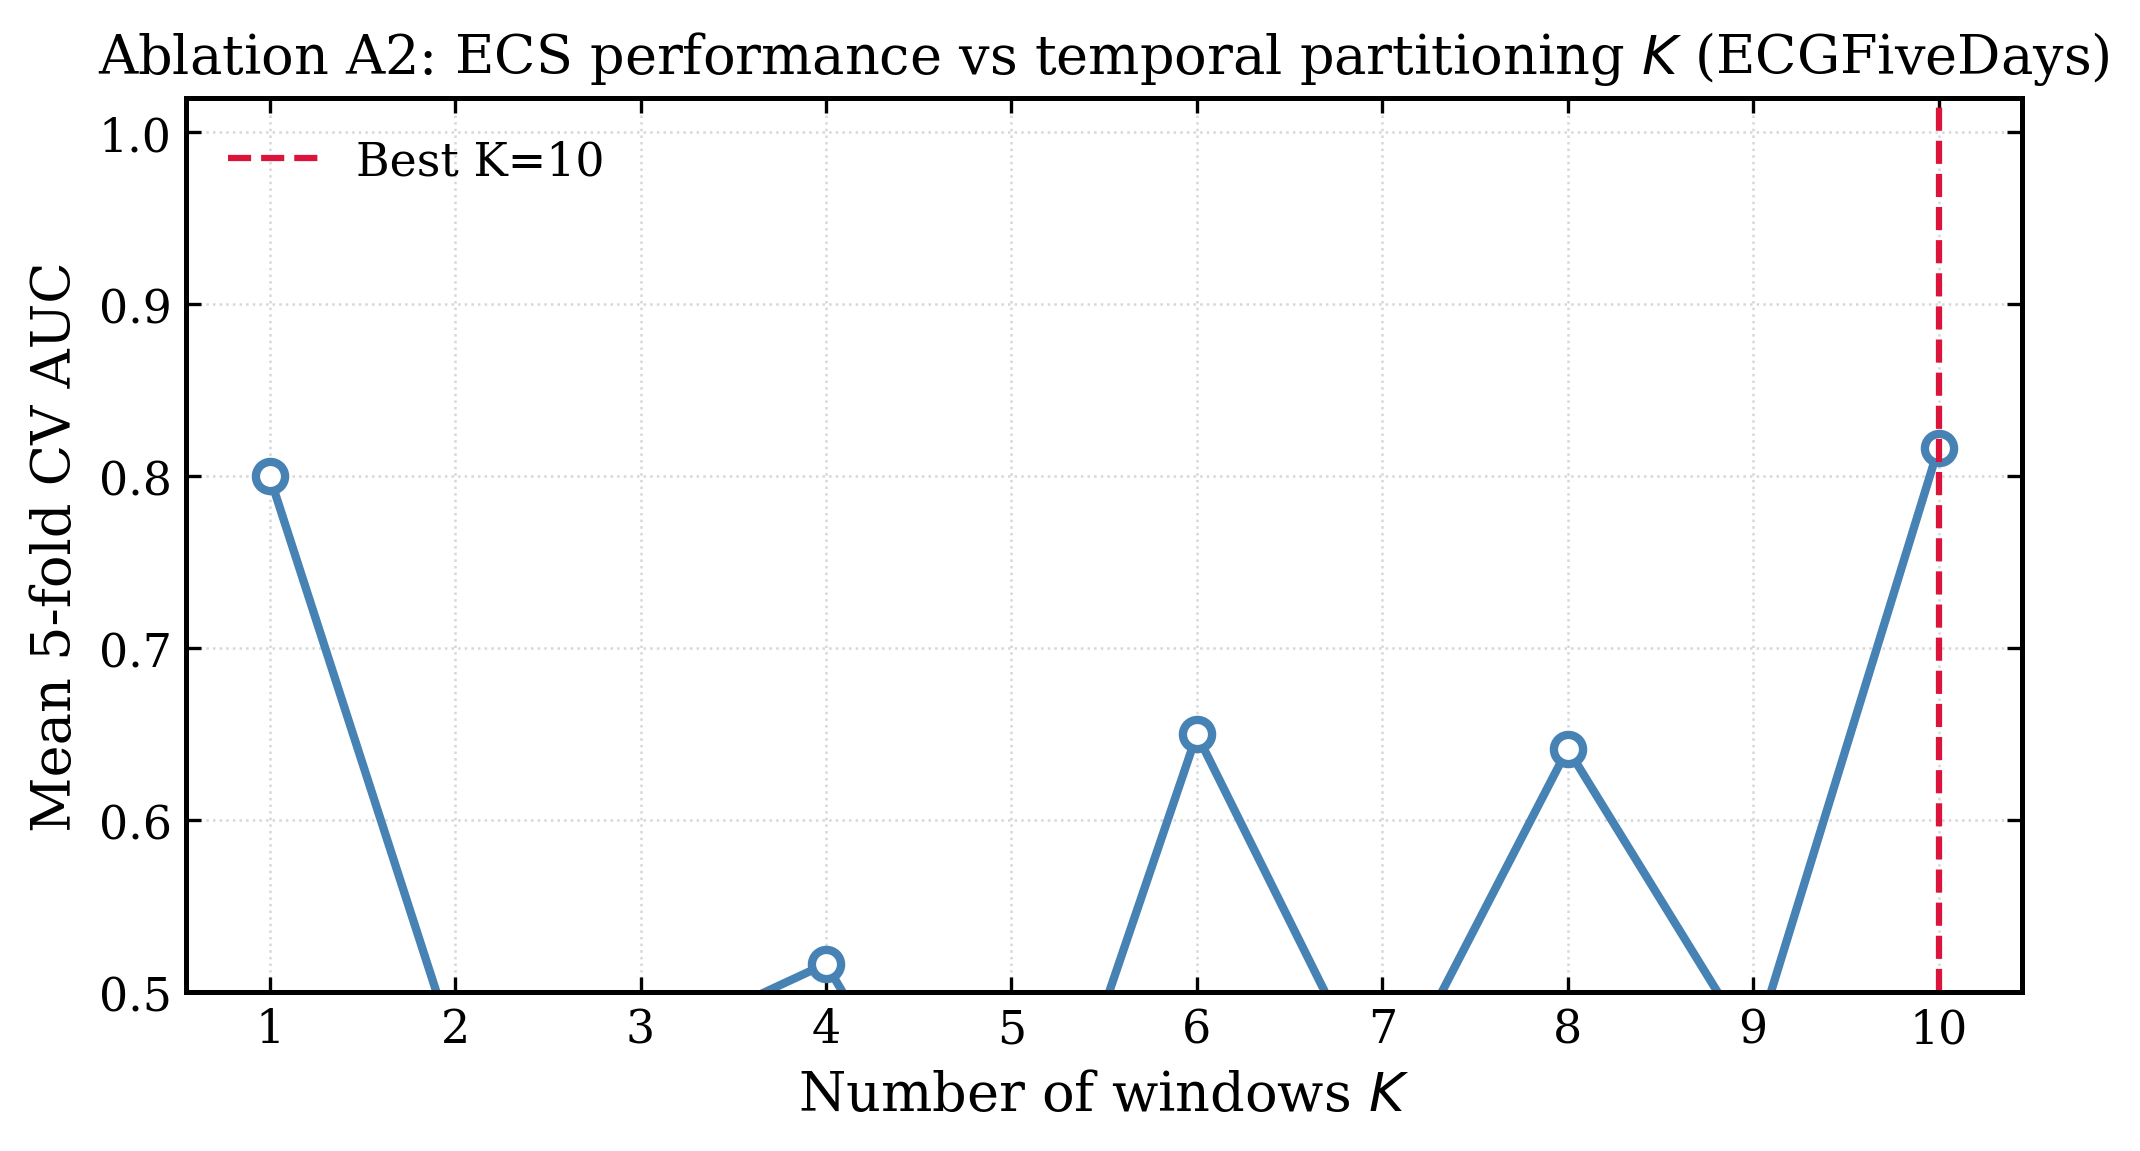

Figure saved.


In [ ]:
# ============================================================
# Figure 1 — K-sweep: CV AUC vs number of windows K
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4), dpi=300)

Ks   = list(k_sweep_results.keys())
AUCs = [k_sweep_results[k] for k in Ks]

ax.plot(Ks, AUCs, "o-", color="steelblue", lw=2, ms=7, markerfacecolor="white",
        markeredgewidth=2)
ax.axvline(BEST_K, color="crimson", ls="--", lw=1.5, label=f"Best K={BEST_K}")
ax.set_xlabel("Number of windows $K$")
ax.set_ylabel("Mean 5-fold CV AUC")
ax.set_title(f"Ablation A2: ECS performance vs temporal partitioning $K$ ({Dataset_name})")
ax.set_xticks(Ks)
ax.legend()
ax.grid(True, ls=":", lw=0.6, alpha=0.5)
ax.set_ylim(0.5, 1.02)
fig.tight_layout()
fig.savefig(f"{Dataset_name}_ablation_K_sweep.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")


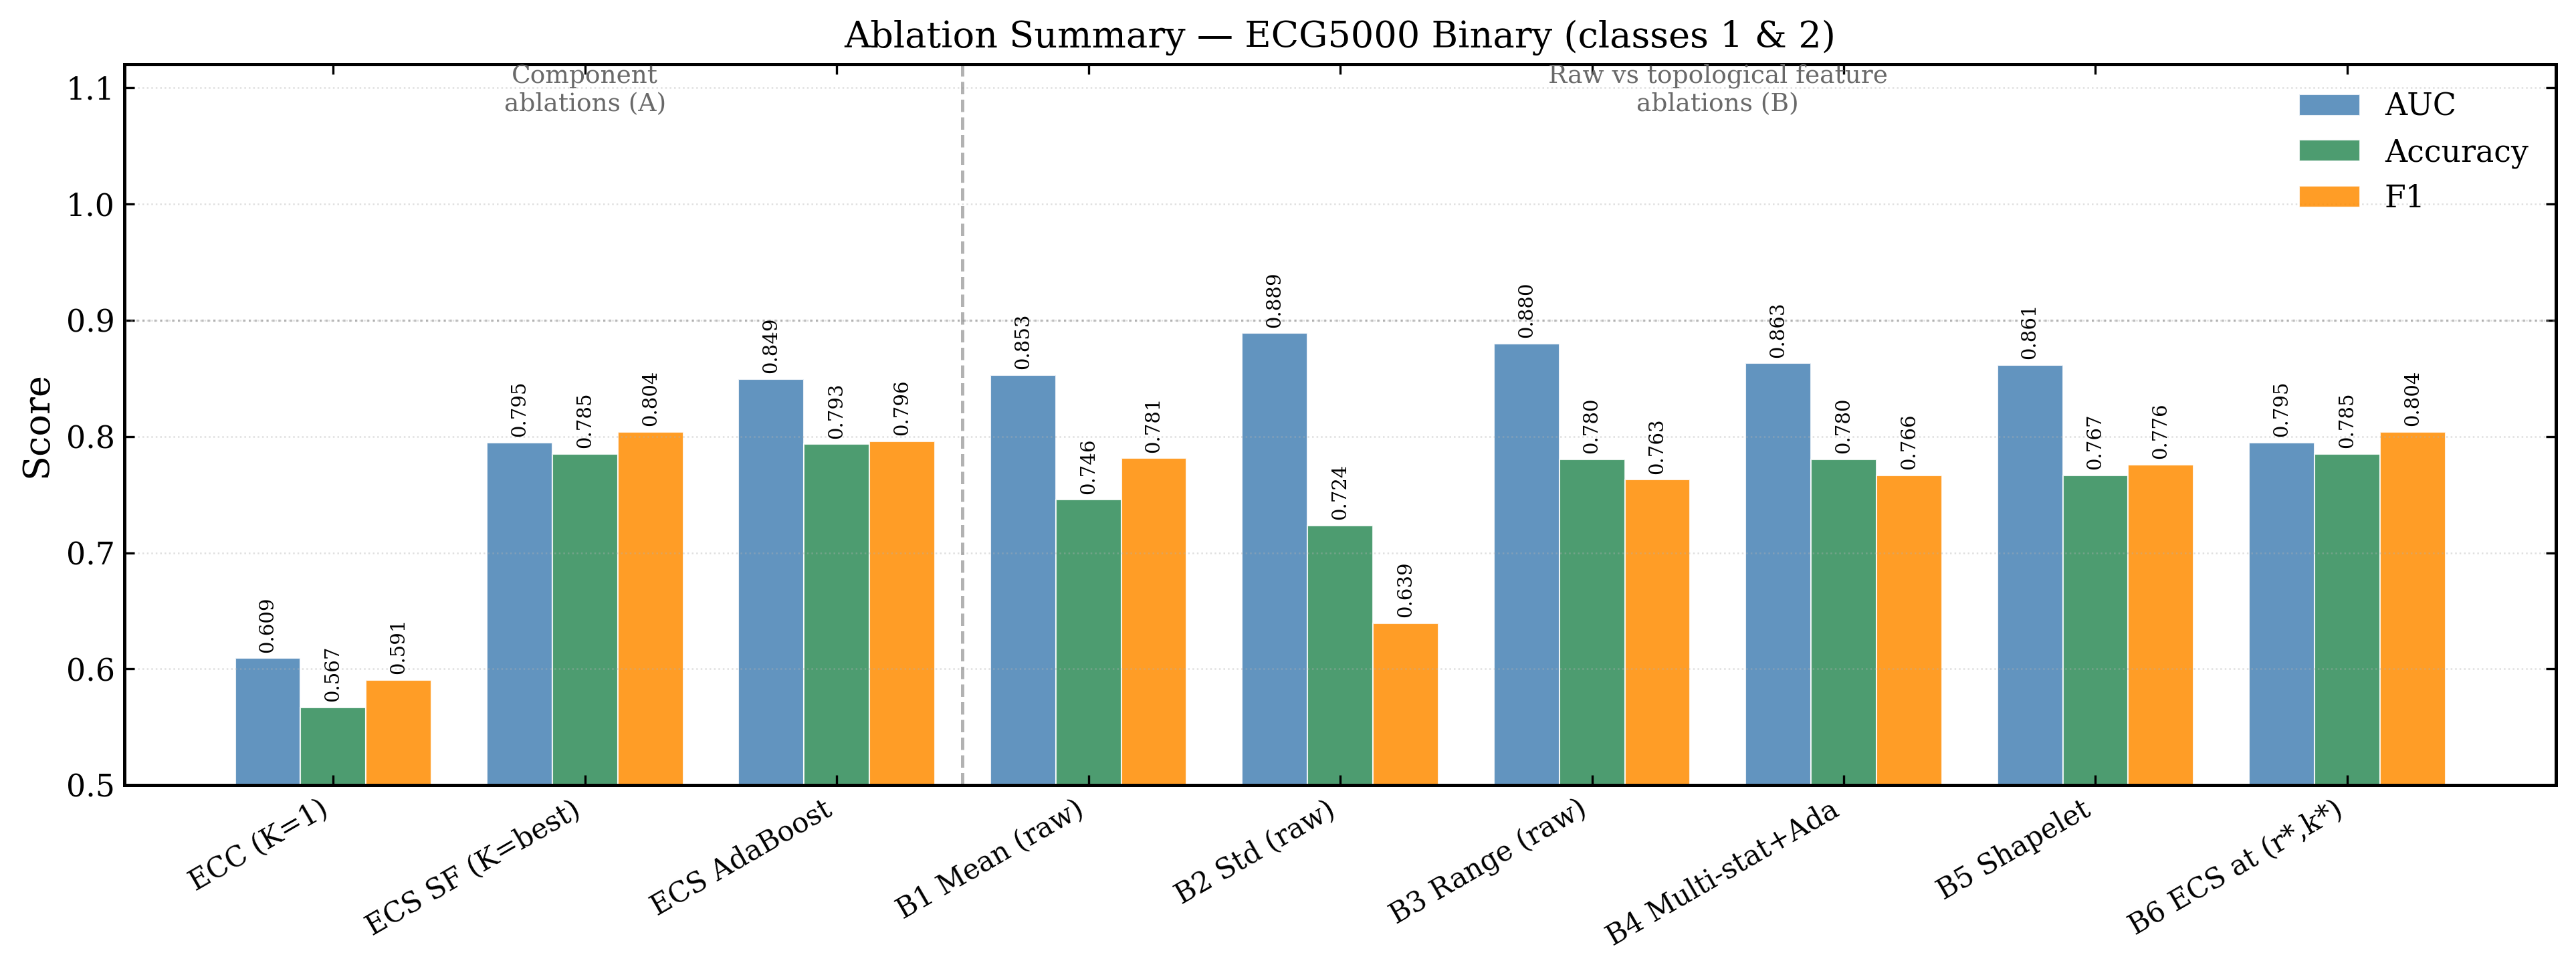

Figure saved.


In [ ]:
# ============================================================
# Figure 2 — Bar chart comparing all ablation configurations
# ============================================================
labels_bar = [c[0] for c in configs]
auc_vals   = [c[2]['auc'] for c in configs]
acc_vals   = [c[2]['acc'] for c in configs]
f1_vals    = [c[2]['f1']  for c in configs]

x = np.arange(len(labels_bar))
width = 0.26

fig, ax = plt.subplots(figsize=(13, 5), dpi=300)

bars_auc = ax.bar(x - width, auc_vals, width, label="AUC",
                   color="steelblue", alpha=0.85, edgecolor="white", lw=0.5)
bars_acc = ax.bar(x,          acc_vals, width, label="Accuracy",
                   color="seagreen",  alpha=0.85, edgecolor="white", lw=0.5)
bars_f1  = ax.bar(x + width,  f1_vals,  width, label="F1",
                   color="darkorange", alpha=0.85, edgecolor="white", lw=0.5)

# Annotate bars with values
for bar in list(bars_auc) + list(bars_acc) + list(bars_f1):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom",
            fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(labels_bar, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0.5, 1.12)
ax.set_title(f"Ablation Summary — ECG5000 Binary (classes 1 & 2)")
ax.legend(loc="upper right")
ax.axhline(0.9, color="gray", ls=":", lw=0.8, alpha=0.5)
ax.grid(axis="y", ls=":", lw=0.6, alpha=0.4)

# Vertical separator between A-ablations and B-ablations
ax.axvline(2.5, color="gray", ls="--", lw=1.2, alpha=0.6)
ax.text(1.0, 1.08, "Component\nablations (A)", ha="center",
        fontsize=9, color="dimgray")
ax.text(5.5, 1.08, "Raw vs topological feature\nablations (B)",
        ha="center", fontsize=9, color="dimgray")

fig.tight_layout()
fig.savefig(f"{Dataset_name}_ablation_bar.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")


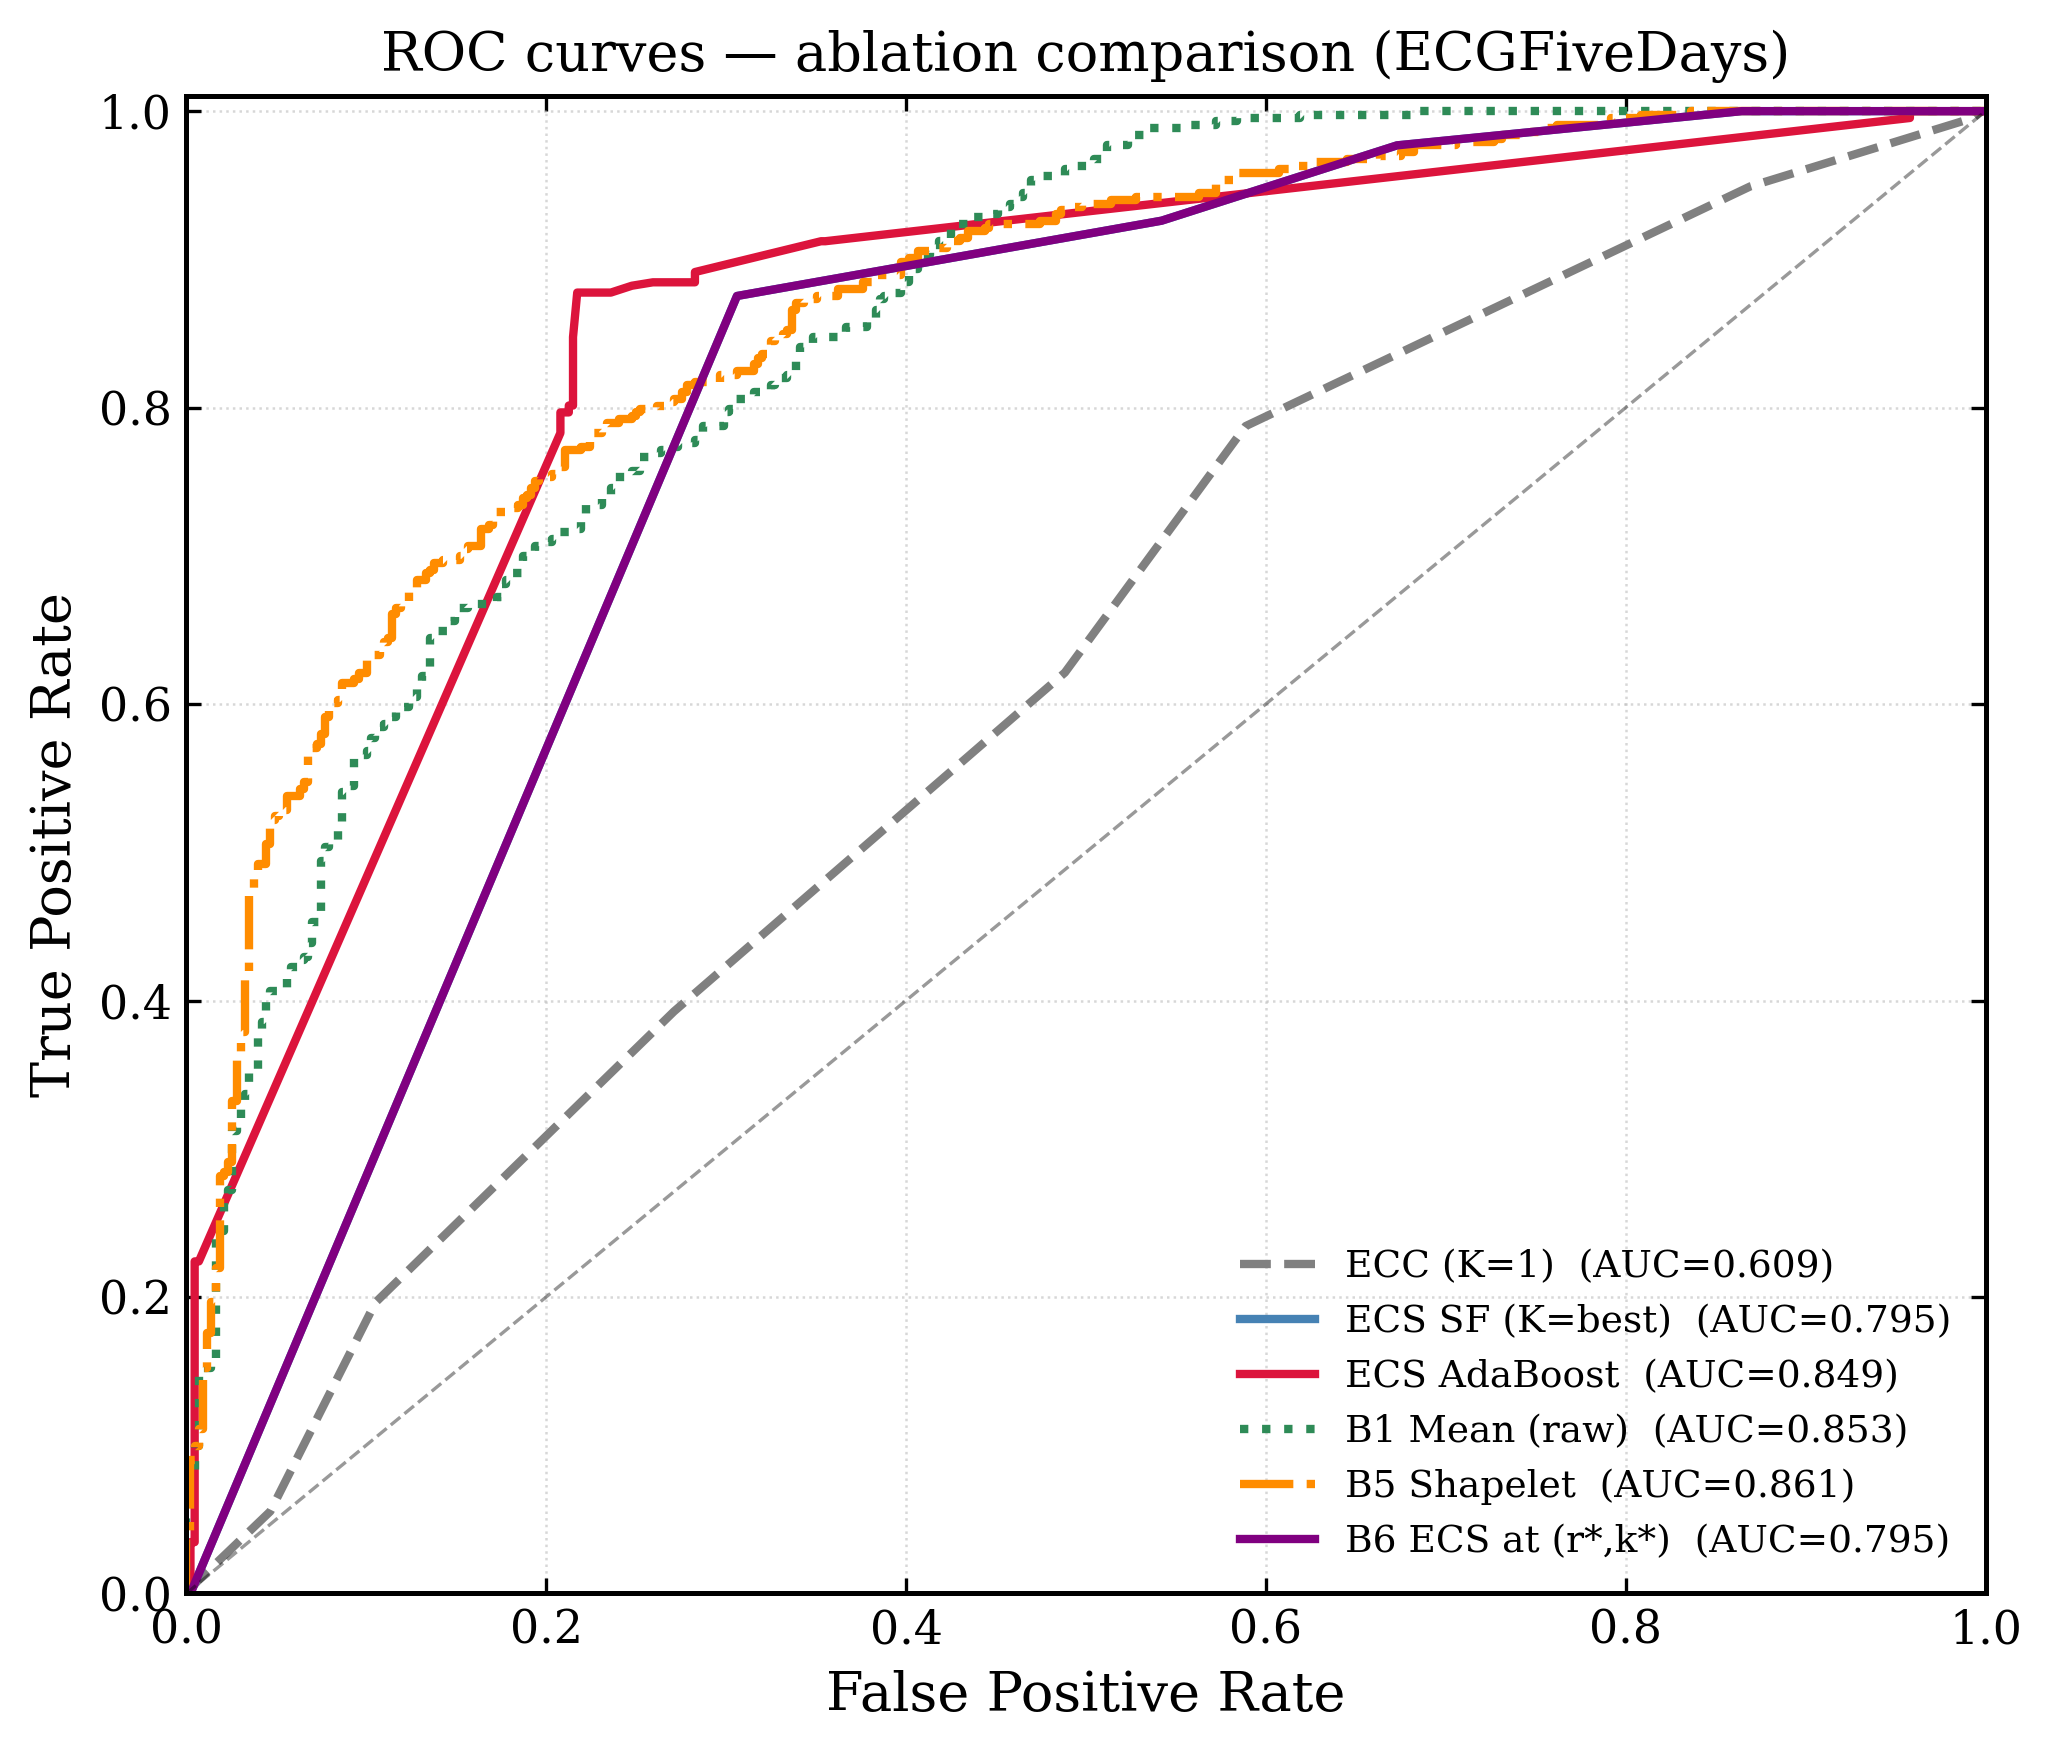

Figure saved.


In [ ]:
# ============================================================
# Figure 3 — ROC curves for key configurations
# ============================================================
key_configs = [
    ("ECC (K=1)",          X_tr_ecc_full, X_te_ecc_full, "dashed",  "gray"),
    ("ECS SF (K=best)",    X_tr_ecs,      X_te_ecs,      "solid",   "steelblue"),
    ("ECS AdaBoost",       X_tr_ecs,      X_te_ecs,      "solid",   "crimson"),
    ("B1 Mean (raw)",      F_tr_raw[:,[0]],F_te_raw[:,[0]],"dotted","seagreen"),
    ("B5 Shapelet",        F_tr_shap,     F_te_shap,     "dashdot", "darkorange"),
    ("B6 ECS at (r*,k*)", F_tr_ecs_single,F_te_ecs_single,"solid", "purple"),
]

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

for name, Xtr, Xte, ls, col in key_configs:
    if name == "ECS AdaBoost":
        clf_tmp = AdaBoostClassifier(
            estimator=None, n_estimators=BEST_K**2,
            learning_rate=0.5, random_state=42)
        clf_tmp.fit(Xtr, y_bin_tr)
        sc = clf_tmp.predict_proba(Xte)[:, 1]
    else:
        # AUC-best single feature
        best_i, best_fl = 0, False
        best_a = -np.inf
        for i in range(Xtr.shape[1]):
            a, fl = get_auc_and_flip(y_bin_tr, Xtr[:, i])
            if a > best_a:
                best_a, best_i, best_fl = a, i, fl
        sc = Xte[:, best_i] * (-1 if best_fl else 1)

    fpr_r, tpr_r, _ = roc_curve(y_bin_te, sc)
    auc_r = roc_auc_score(y_bin_te, sc)
    ax.plot(fpr_r, tpr_r, lw=2, ls=ls, color=col,
            label=f"{name}  (AUC={auc_r:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC curves — ablation comparison ({Dataset_name})")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, ls=":", lw=0.6, alpha=0.5)
ax.set_xlim(0, 1);  ax.set_ylim(0, 1.01)
fig.tight_layout()
fig.savefig(f"{Dataset_name}_ablation_roc.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")


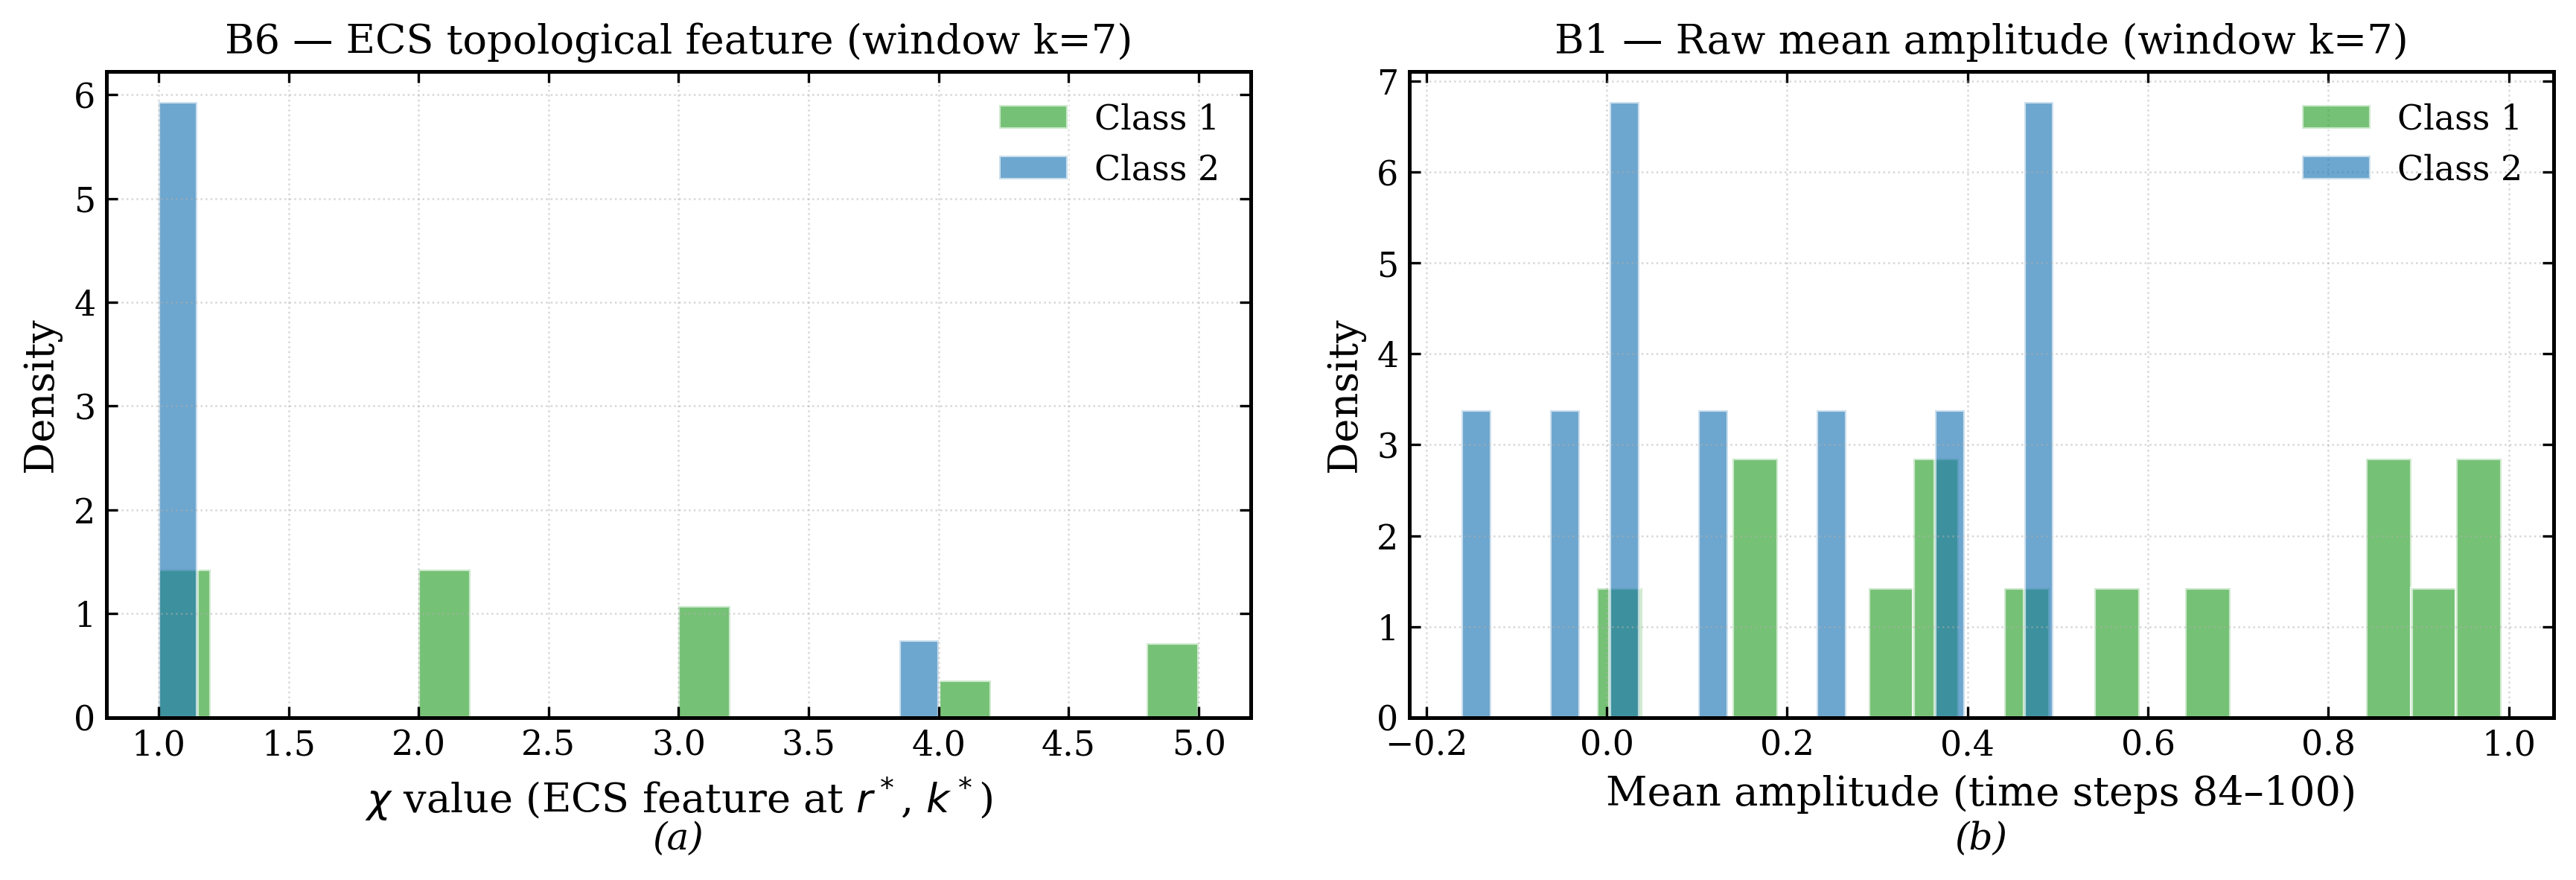

Figure saved.


In [ ]:
# ============================================================
# Figure 4 — Side-by-side density: ECS feature vs mean amplitude
#            both from best window k*
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=300)

# Left: ECS feature distribution
ecs_sc_tr = X_tr_ecs[:, feat_idx] * (-1 if res_sf.get('flip', False) else 1)
ax_l = axes[0]
ax_l.hist(ecs_sc_tr[y_bin_tr == 0], bins=20, alpha=0.65, density=True,
           color="tab:green", edgecolor="white", lw=0.4,
           label=f"Class {labels[0]}")
ax_l.hist(ecs_sc_tr[y_bin_tr == 1], bins=20, alpha=0.65, density=True,
           color="tab:blue", edgecolor="white", lw=0.4,
           label=f"Class {labels[1]}")
ax_l.set_xlabel(r"$\chi$ value (ECS feature at $r^*$, $k^*$)")
ax_l.set_ylabel("Density")
ax_l.set_title(f"B6 — ECS topological feature (window k={best_k_val})")
ax_l.legend()
ax_l.grid(True, ls=":", lw=0.6, alpha=0.5)
ax_l.text(0.5, -0.16, "(a)", transform=ax_l.transAxes,
          ha="center", va="top", fontsize=12, fontstyle="italic")

# Right: Mean amplitude distribution
ax_r = axes[1]
ax_r.hist(F_tr_raw[y_bin_tr == 0, 0], bins=20, alpha=0.65, density=True,
           color="tab:green", edgecolor="white", lw=0.4,
           label=f"Class {labels[0]}")
ax_r.hist(F_tr_raw[y_bin_tr == 1, 0], bins=20, alpha=0.65, density=True,
           color="tab:blue", edgecolor="white", lw=0.4,
           label=f"Class {labels[1]}")
ax_r.set_xlabel(f"Mean amplitude (time steps {raw_start}–{raw_end})")
ax_r.set_ylabel("Density")
ax_r.set_title(f"B1 — Raw mean amplitude (window k={best_k_val})")
ax_r.legend()
ax_r.grid(True, ls=":", lw=0.6, alpha=0.5)
ax_r.text(0.5, -0.16, "(b)", transform=ax_r.transAxes,
          ha="center", va="top", fontsize=12, fontstyle="italic")

fig.tight_layout(pad=2.0)
fig.savefig(f"{Dataset_name}_ablation_density.pdf", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")


## Section 9 — LaTeX Table for Manuscript

In [ ]:
# ============================================================
# Print a LaTeX-ready ablation table for the manuscript
# ============================================================

print(r"\begin{table}[ht]")
print(r"\centering")
print(r"\renewcommand{\arraystretch}{1.4}")
print(r"\small")
print(r"\begin{tabular}{llccccc}")
print(r"\hline\hline")
print(r"\textbf{Label} & \textbf{Configuration} & \textbf{AUC} & "
      r"\textbf{Acc.} & \textbf{Prec.} & \textbf{Recall} & \textbf{F1} \\")
print(r"\hline")
print(r"\multicolumn{7}{l}{\textit{(A) Component ablations — K-window and "
      r"classifier design}} \\")

for label, desc, res in configs[:3]:
    print(f"{label} & {desc} & {res['auc']:.4f} & {res['acc']:.4f} & "
          f"{res['prec']:.4f} & {res['rec']:.4f} & {res['f1']:.4f} \\\\")

print(r"\hline")
print(r"\multicolumn{7}{l}{\textit{(B) Topological vs raw feature comparison"
      r" (same temporal window $k^*$)}} \\")

for label, desc, res in configs[3:]:
    print(f"{label} & {desc} & {res['auc']:.4f} & {res['acc']:.4f} & "
          f"{res['prec']:.4f} & {res['rec']:.4f} & {res['f1']:.4f} \\\\")

print(r"\hline\hline")
print(r"\end{tabular}")
print(r"\caption{Ablation results on the \textit{ECG5000} binary dataset. "
      r"Part~(A) tests component contributions; "
      r"Part~(B) compares the ECS topological feature with raw signal statistics "
      r"extracted from the same temporal window $k^*$. "
      r"All methods use the same UCR train/test split.}")
print(r"\label{tab:ablation}")
print(r"\end{table}")


\begin{table}[ht]
\centering
\renewcommand{\arraystretch}{1.4}
\small
\begin{tabular}{llccccc}
\hline\hline
\textbf{Label} & \textbf{Configuration} & \textbf{AUC} & \textbf{Acc.} & \textbf{Prec.} & \textbf{Recall} & \textbf{F1} \\
\hline
\multicolumn{7}{l}{\textit{(A) Component ablations — K-window and classifier design}} \\
ECC (K=1) & No temporal partitioning (EC curve only) & 0.6093 & 0.5668 & 0.5628 & 0.6212 & 0.5906 \\
ECS SF (K=best) & ECS single feature  K=10 & 0.7949 & 0.7851 & 0.7431 & 0.8753 & 0.8038 \\
ECS AdaBoost & ECS AdaBoost  K=10  T=100 & 0.8494 & 0.7933 & 0.7904 & 0.8014 & 0.7959 \\
\hline
\multicolumn{7}{l}{\textit{(B) Topological vs raw feature comparison (same temporal window $k^*$)}} \\
B1 Mean (raw) & Mean amplitude in window k=7 & 0.8527 & 0.7456 & 0.6884 & 0.9030 & 0.7812 \\
B2 Std (raw) & Std amplitude in window k=7 & 0.8887 & 0.7236 & 0.9295 & 0.4873 & 0.6394 \\
B3 Range (raw) & Range in window k=7 & 0.8799 & 0.7805 & 0.8352 & 0.7021 & 0.7629 \\
B4 Multi-stat